## Konfigurasi Runtime (GPU)

In [ ]:
!nvidia-smi

Sat Jul 11 11:19:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import Library

In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.8 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import yaml
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/deteksi_kematangan_pala"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
print("Folder proyek di Drive:", DRIVE_PROJECT_DIR)


Mounted at /content/drive
Folder proyek di Drive: /content/drive/MyDrive/deteksi_kematangan_pala


## Import Dataset dari Roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="eoo0I6TC06OxO4VlqMI4")
project = rf.workspace("kevin-workspace-lpvw9").project("deteksi-kematangan-pala")
version = project.version(1)
dataset = version.download("yolov11")

from roboflow import Roboflow
rf = Roboflow(api_key="eoo0I6TC06OxO4VlqMI4")
project = rf.workspace("kevin-workspace-lpvw9").project("deteksi-kematangan-pala")
version = project.version(1)
dataset = version.download("yolov11")

print("Dataset location:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteksi-Kematangan-Pala-1 in yolov11:: 100%|██████████| 4005/4005 [00:00<00:00, 6412.70it/s]


loading Roboflow workspace...
loading Roboflow project...
Dataset location: /content/Deteksi-Kematangan-Pala-1


## Verifikasi Dataset


In [ ]:
with open(f"{dataset.location}/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)
# Pastikan nc: 2, dan names berisi kelas 'matang' dan 'mentah' (belum masak)


{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['matang', 'mentah'], 'roboflow': {'workspace': 'kevin-workspace-lpvw9', 'project': 'deteksi-kematangan-pala', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/kevin-workspace-lpvw9/deteksi-kematangan-pala/dataset/1'}}


## Verifikasi Label Dataset


In [ ]:
sample_label_dir = f"{dataset.location}/train/labels"
sample_label_file = glob.glob(f"{sample_label_dir}/*.txt")[0]

with open(sample_label_file, "r") as f:
    print(f"Contoh isi label ({sample_label_file}):")
    print(f.read())
# Format: <class_id> <x_center> <y_center> <width> <height> (ternormalisasi 0-1)


Contoh isi label (/content/Deteksi-Kematangan-Pala-1/train/labels/IMG_9892_JPG.rf.21cd1c3d3864a0b543f434ca63e9c041.txt):
0 0.48984375 0.525 0.30390625 0.3296875


## Visualisasi Dataset

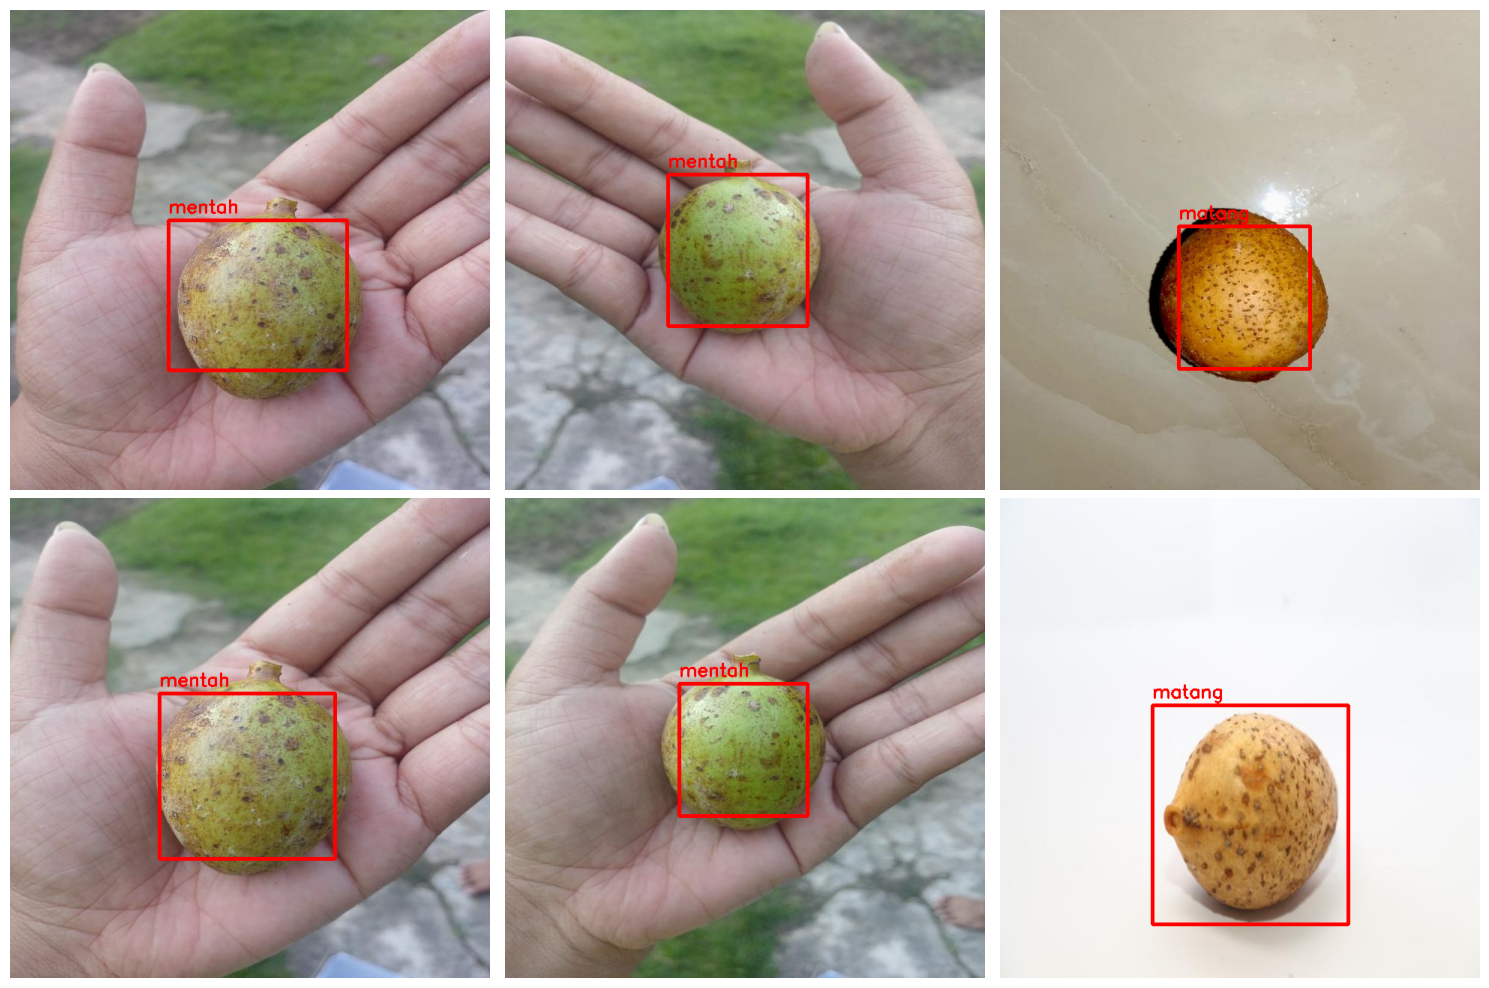

In [ ]:
import cv2

sample_images = glob.glob(f"{dataset.location}/train/images/*.jpg")[:6]
class_names = data_yaml["names"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                cv2.putText(img, class_names[int(cls)], (x1, max(y1 - 10, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Verifikasi Split Dataset

In [ ]:
for split in ["train", "valid", "test"]:
    path = f"{dataset.location}/{split}/images"
    if os.path.exists(path):
        count = len(glob.glob(f"{path}/*.jpg")) + len(glob.glob(f"{path}/*.png"))
        print(f"{split.capitalize():8s}: {count} citra")


Train   : 1600 citra
Valid   : 200 citra
Test    : 200 citra


## Pembuatan Model YOLOv10 & YOLOv12

In [ ]:
model_v10 = YOLO("yolov10n.pt")
model_v12 = YOLO("yolo12n.pt")

print("Arsitektur YOLOv10:", model_v10.model.yaml.get("yaml_file"))
print("Arsitektur YOLOv12:", model_v12.model.yaml.get("yaml_file"))
# Pastikan tidak ada yang menunjukkan 'yolo26n.yaml' atau arsitektur lain di luar dugaan


Arsitektur YOLOv10: yolov10n.yaml
Arsitektur YOLOv12: yolov12n.yaml


## Pelatihan Model YOLOv10 & YOLOv12


In [ ]:
results_v10 = model_v10.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=f"{DRIVE_PROJECT_DIR}/hasil_training",
    name="yolov10_pala"
)


Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteksi-Kematangan-Pala-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10_pala, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
results_v12 = model_v12.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project=f"{DRIVE_PROJECT_DIR}/hasil_training",
    name="yolov12_pala"
)


Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteksi-Kematangan-Pala-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov12_pala, nbs=64, nms=False, opset=None, optimize=False, optimizer

Kurva loss pelatihan masing-masing model:

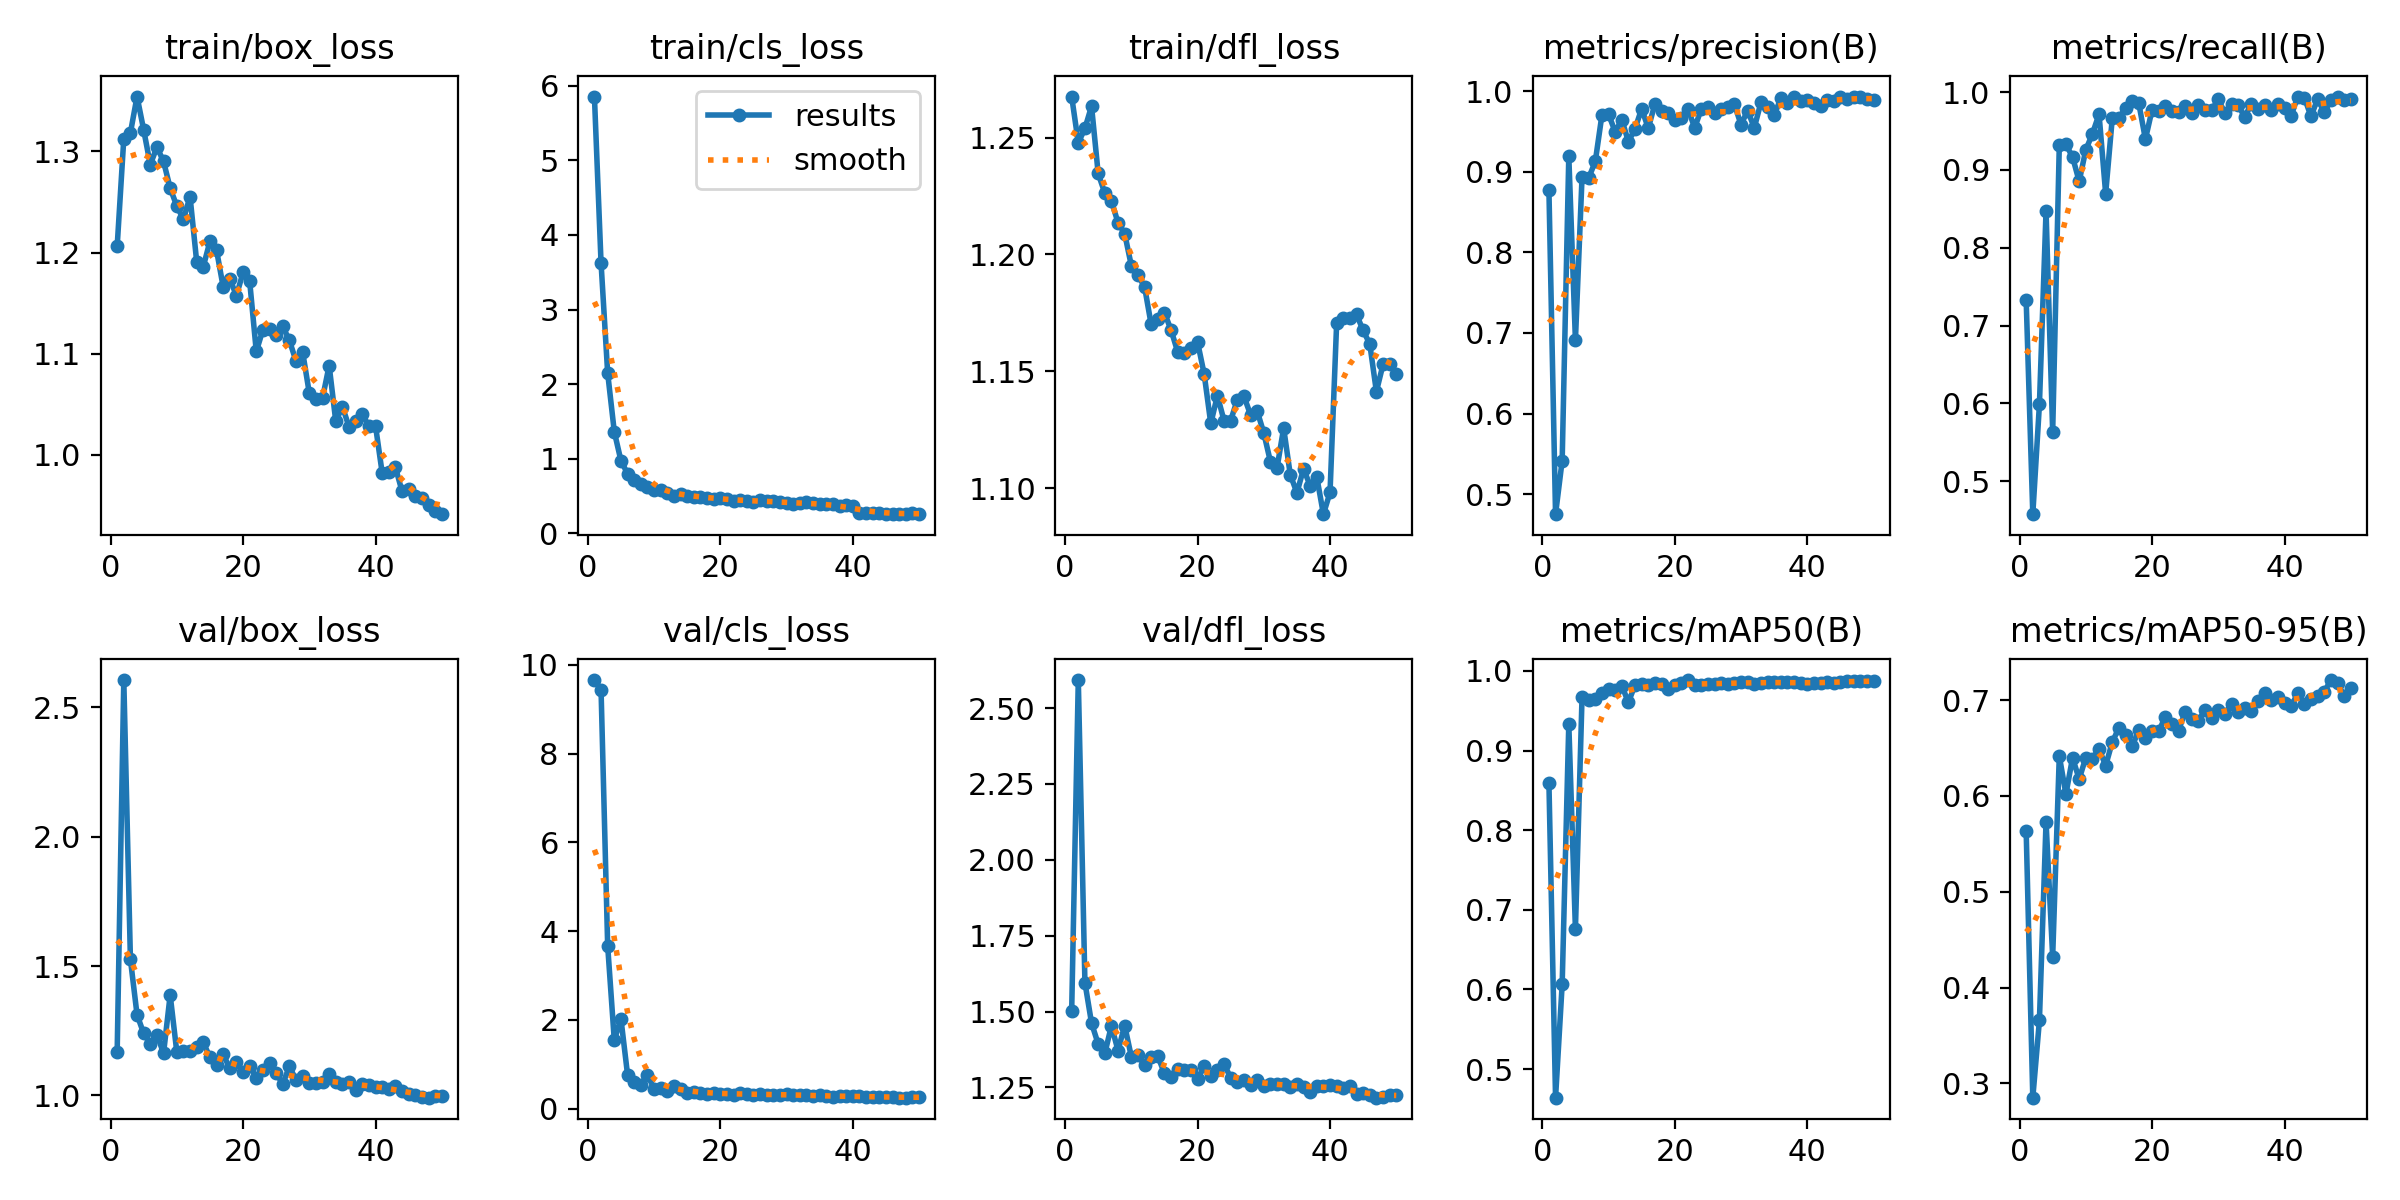

In [ ]:
display(Image(filename=f"{DRIVE_PROJECT_DIR}/hasil_training/yolov10_pala/results.png"))


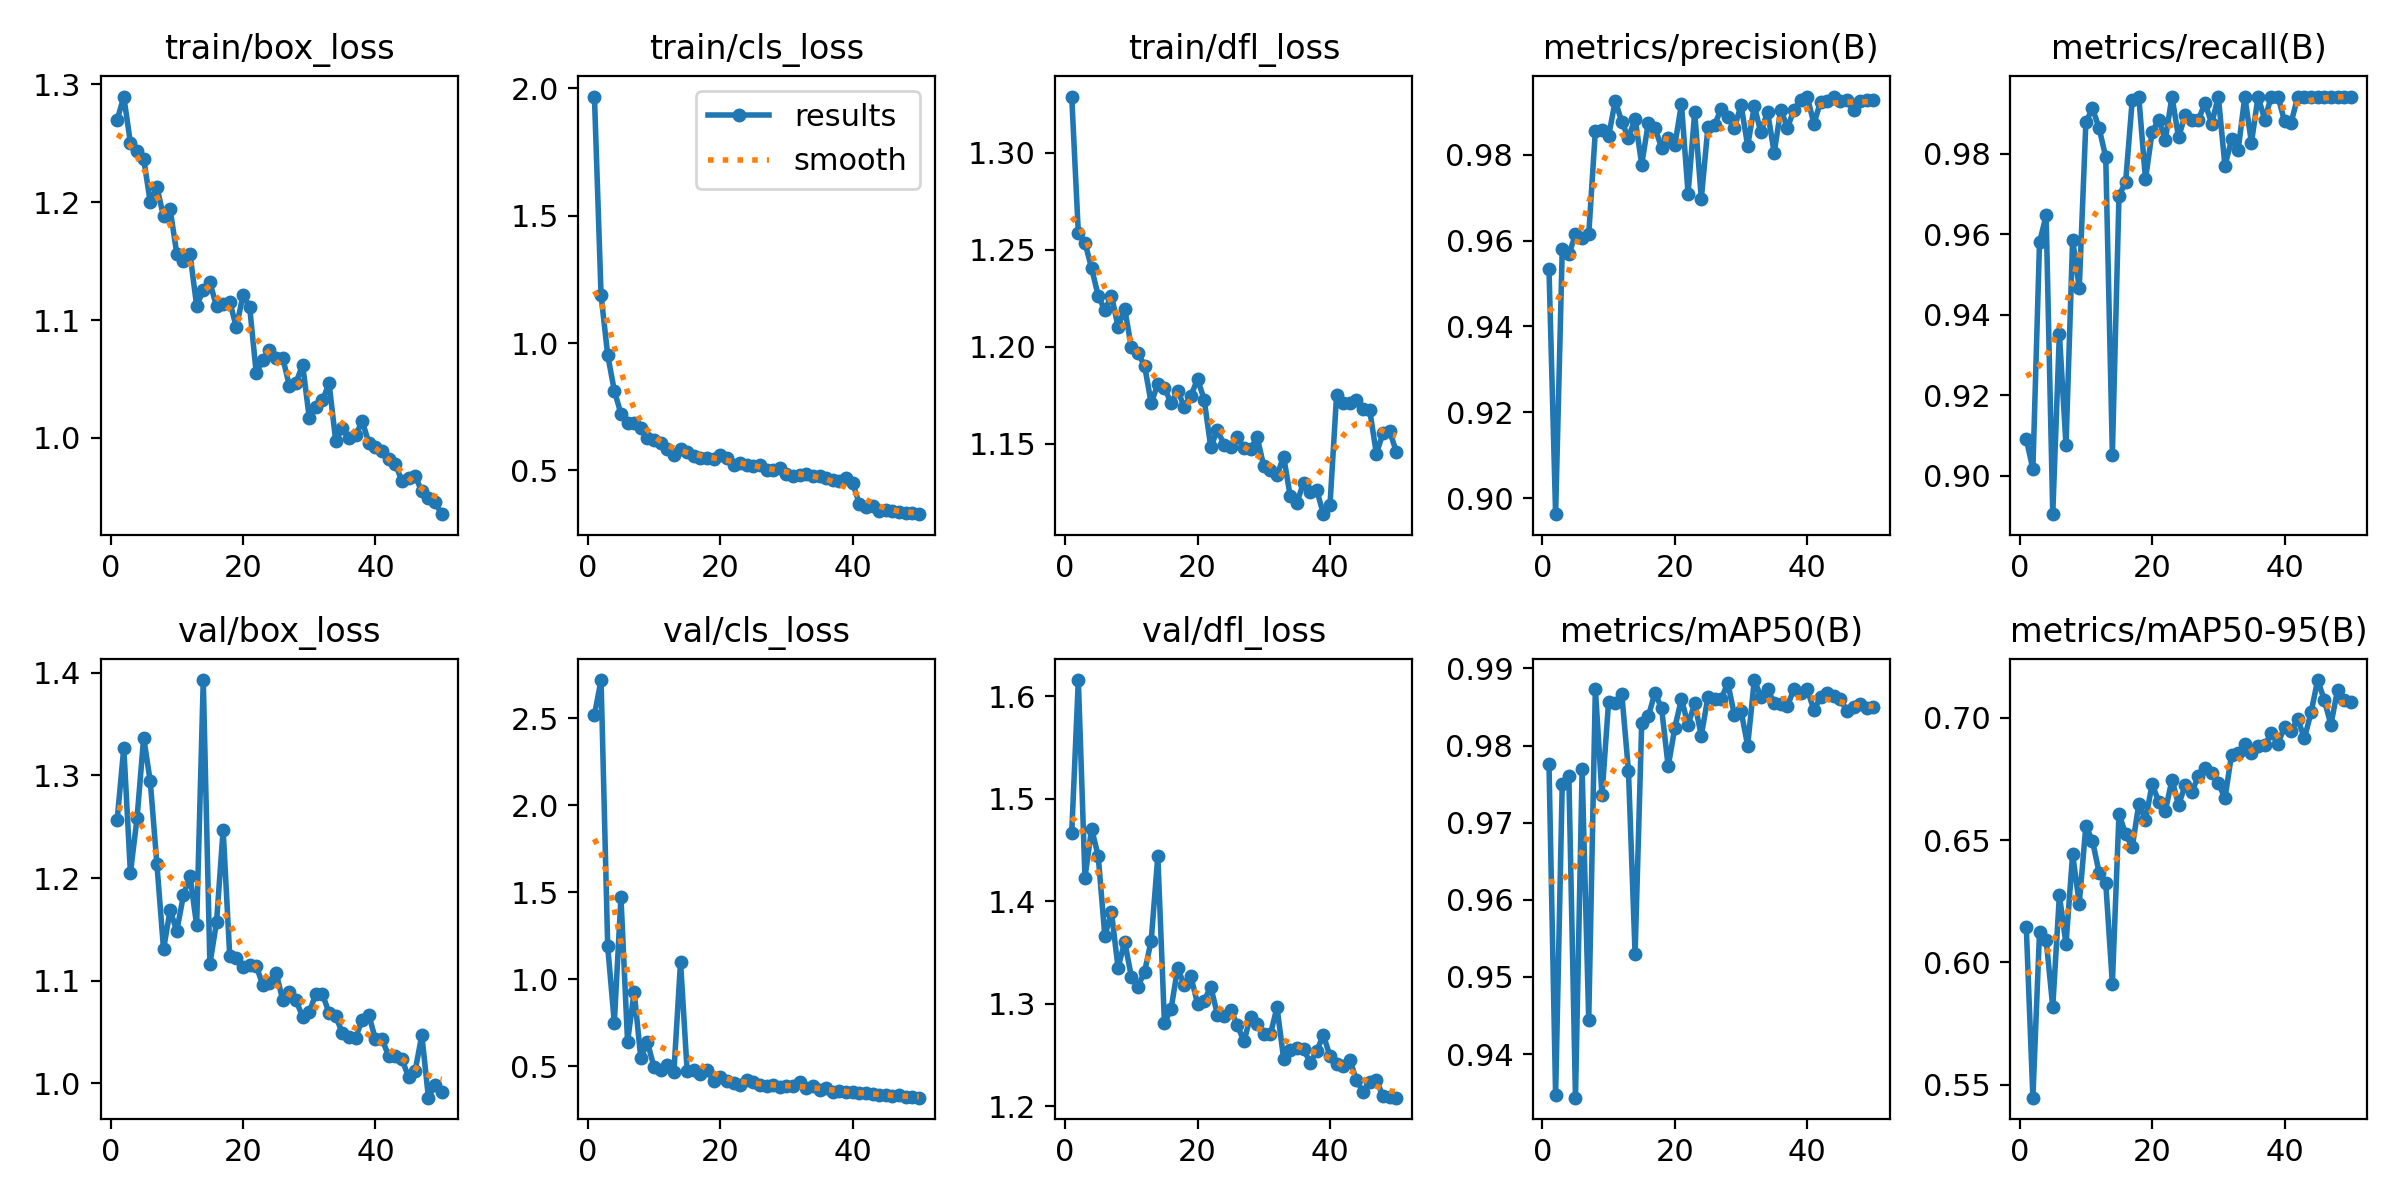

In [ ]:
display(Image(filename=f"{DRIVE_PROJECT_DIR}/hasil_training/yolov12_pala/results.png"))


## Evaluasi Model


In [ ]:
metrics_v10 = model_v10.val(data=f"{dataset.location}/data.yaml", split="test")

print("=== YOLOv10 ===")
print(f"Precision      : {metrics_v10.box.mp:.4f}")
print(f"Recall         : {metrics_v10.box.mr:.4f}")
print(f"mAP@0.5        : {metrics_v10.box.map50:.4f}")
print(f"mAP@0.5:0.95   : {metrics_v10.box.map:.4f}")


Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,558 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1120.3±437.5 MB/s, size: 27.8 KB)
val: Scanning /content/Deteksi-Kematangan-Pala-1/test/labels... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 2.3Kit/s 0.1s
val: New cache created: /content/Deteksi-Kematangan-Pala-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.7it/s 4.8s
                   all        200        201      0.997      0.995       0.99      0.721
                matang         97         98      0.999       0.99      0.985      0.755
                mentah        103        103      0.996          1      0.995      0.687
Speed: 6.1ms preprocess, 5.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
=== YOLOv10 

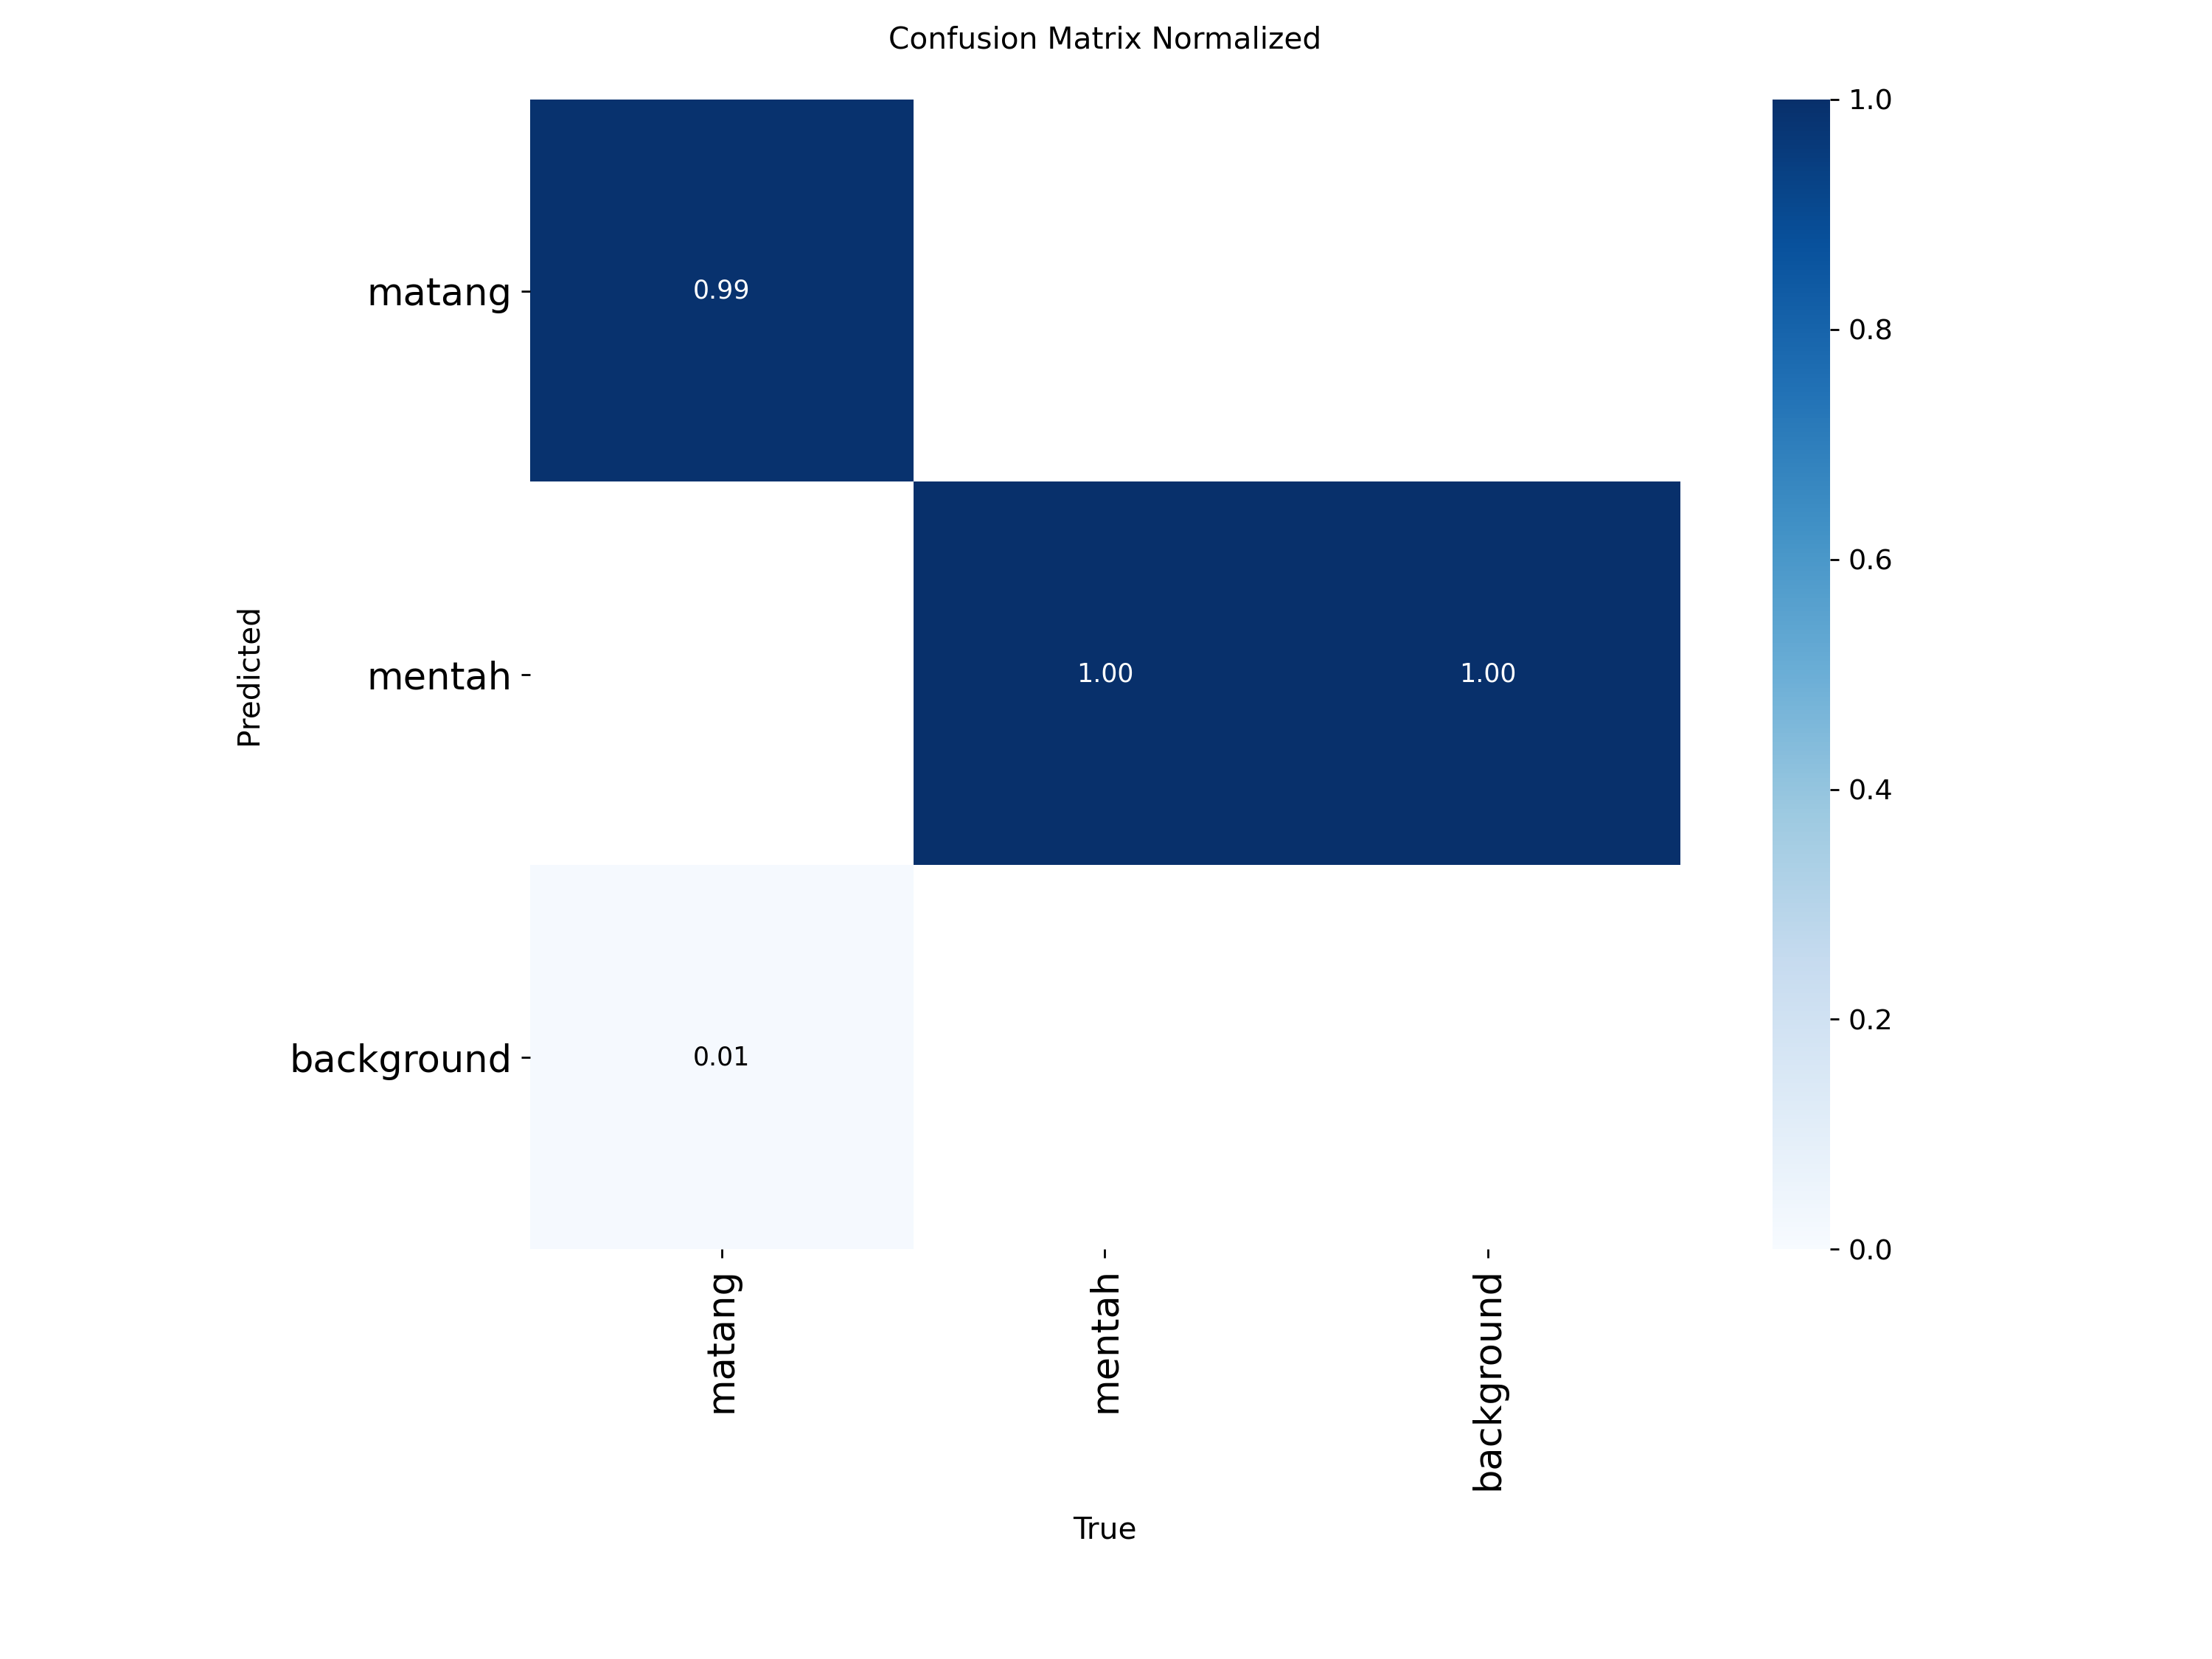

In [ ]:
display(Image(filename=f"{metrics_v10.save_dir}/confusion_matrix_normalized.png"))


In [ ]:
metrics_v12 = model_v12.val(data=f"{dataset.location}/data.yaml", split="test")

print("=== YOLOv12 ===")
print(f"Precision      : {metrics_v12.box.mp:.4f}")
print(f"Recall         : {metrics_v12.box.mr:.4f}")
print(f"mAP@0.5        : {metrics_v12.box.map50:.4f}")
print(f"mAP@0.5:0.95   : {metrics_v12.box.map:.4f}")


Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1017.4±516.1 MB/s, size: 29.7 KB)
val: Scanning /content/Deteksi-Kematangan-Pala-1/test/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 55.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.8it/s 3.4s
                   all        200        201      0.993       0.99      0.989      0.722
                matang         97         98      0.998       0.99      0.985      0.742
                mentah        103        103      0.989       0.99      0.993      0.701
Speed: 2.9ms preprocess, 6.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2
=== YOLOv12 ===
Precision      : 0.9933
Recall         : 0.9900
mAP@0.5        :

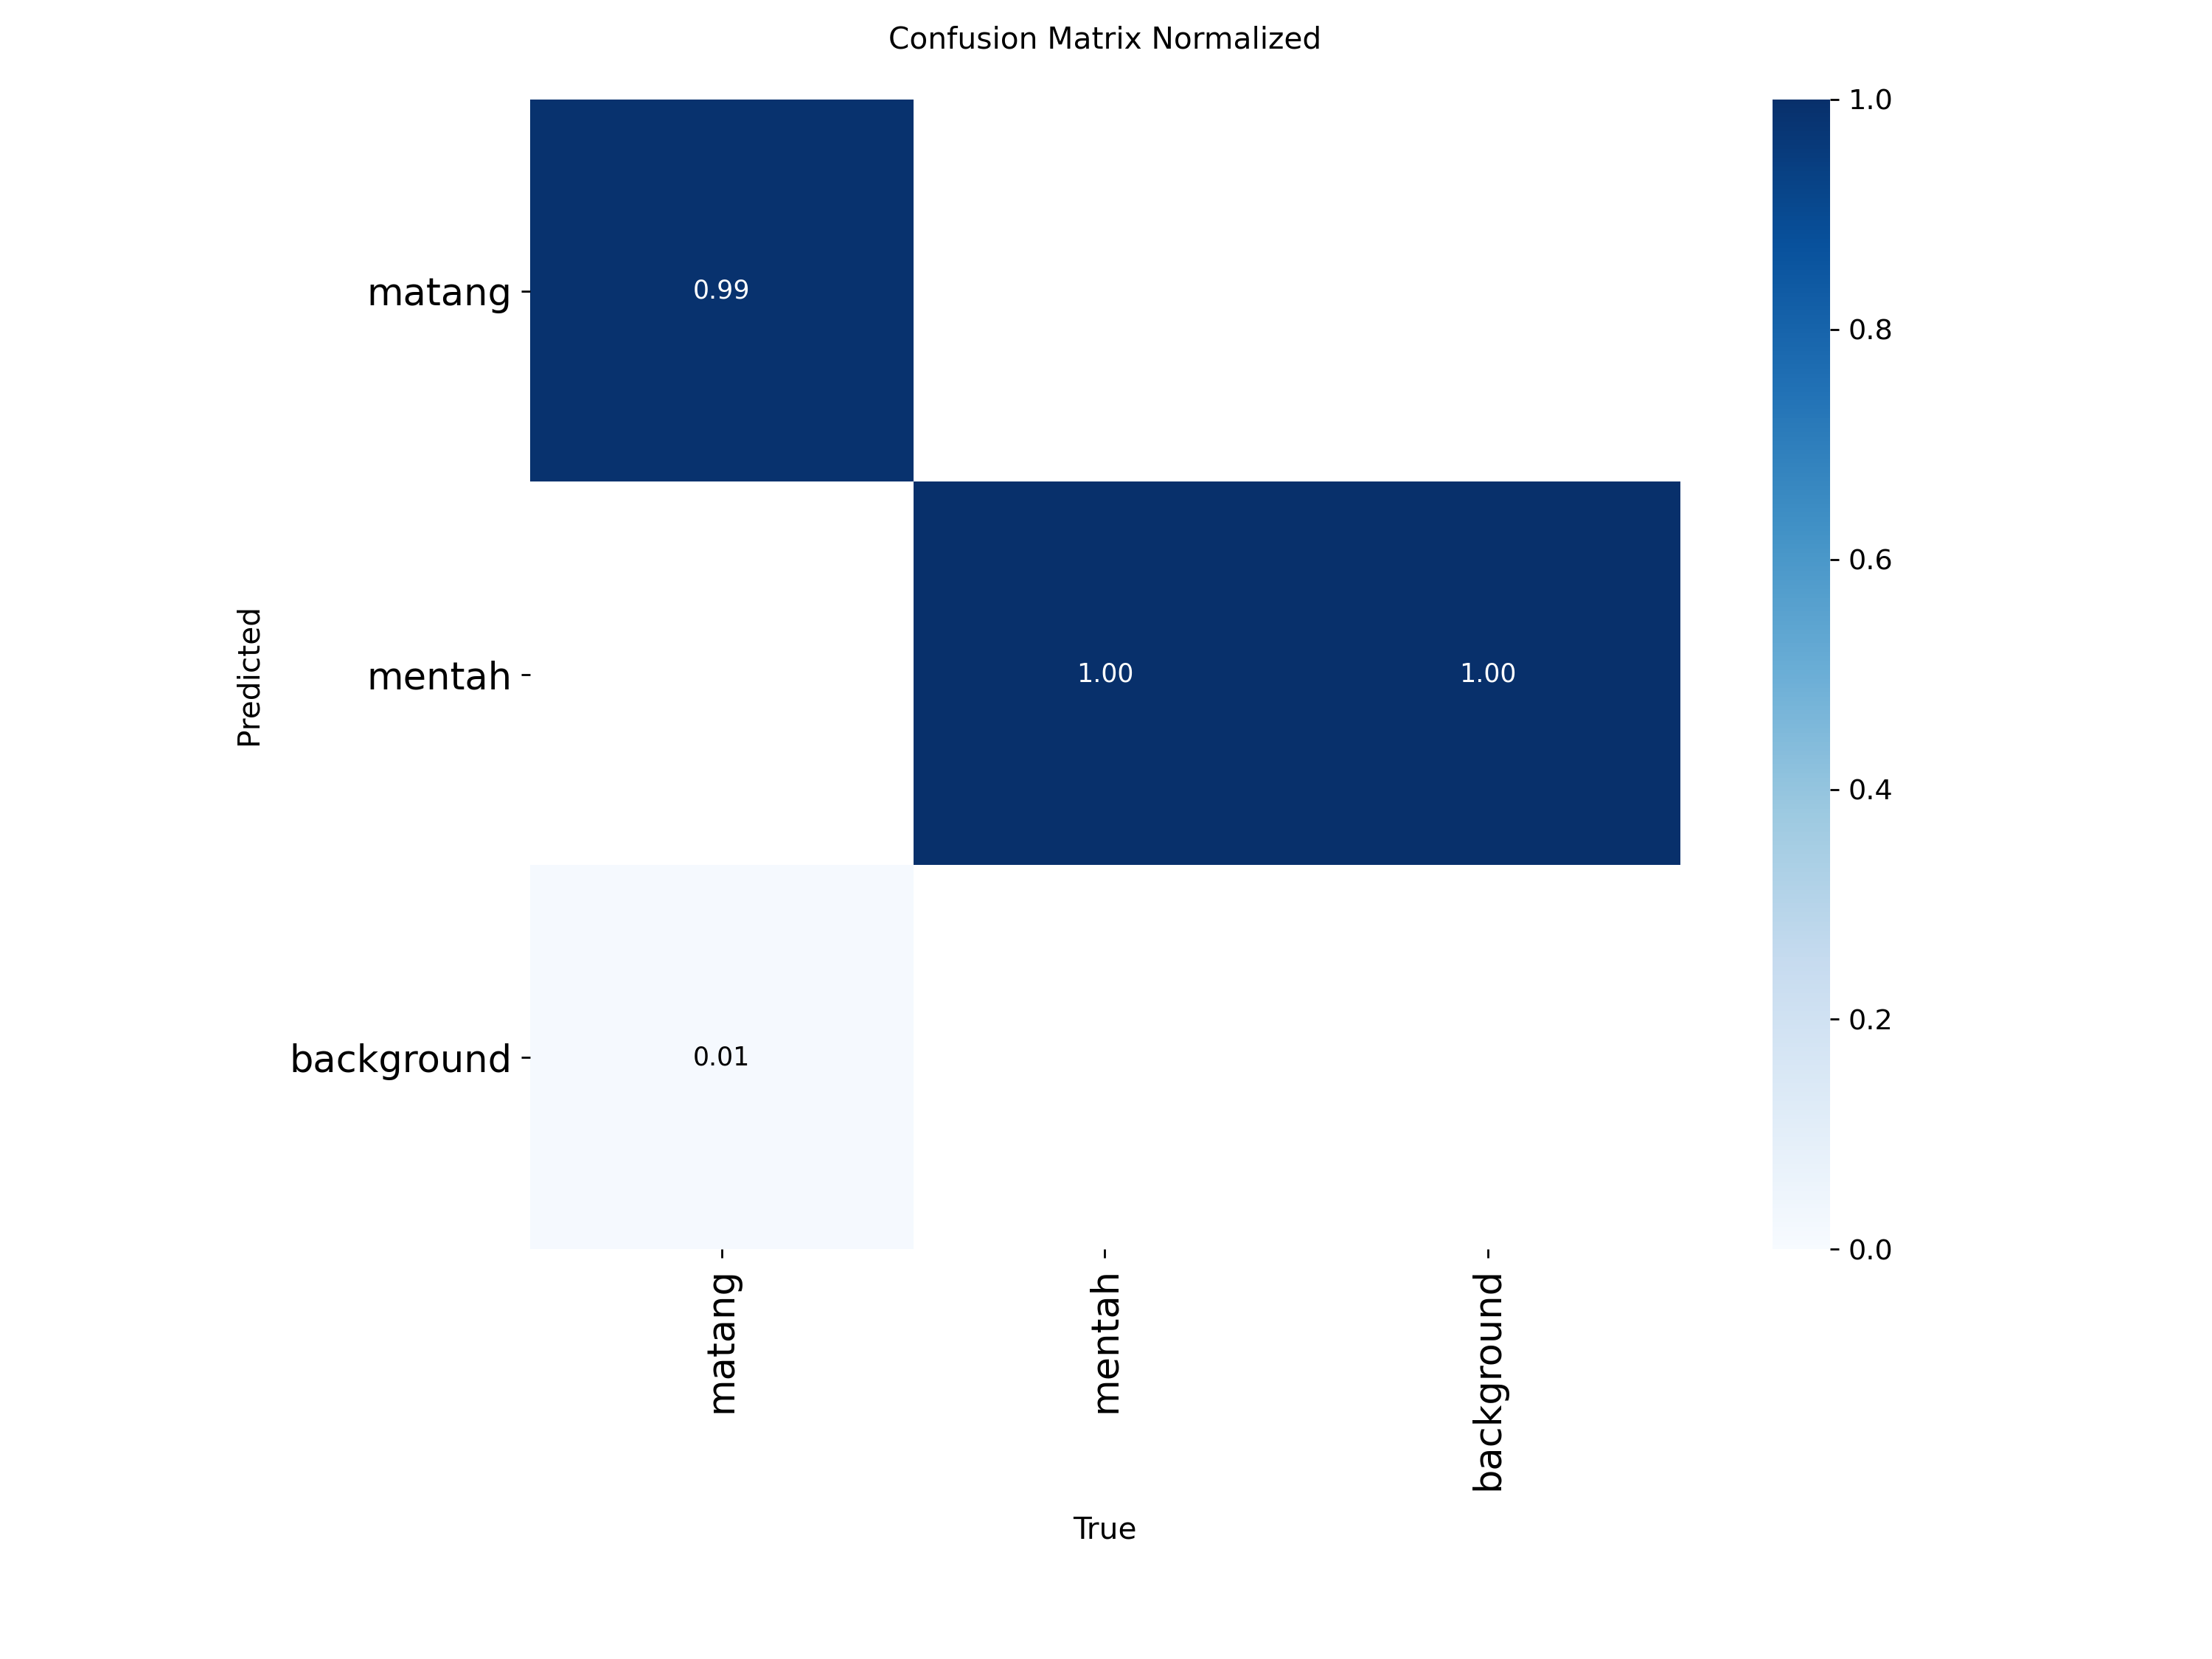

In [ ]:
display(Image(filename=f"{metrics_v12.save_dir}/confusion_matrix_normalized.png"))


## Save Model

In [ ]:
BEST_MODEL_V10 = f"{DRIVE_PROJECT_DIR}/hasil_training/yolov10_pala/weights/best.pt"
BEST_MODEL_V12 = f"{DRIVE_PROJECT_DIR}/hasil_training/yolov12_pala/weights/best.pt"

print("Path model YOLOv10 tersimpan di:", BEST_MODEL_V10, "| Ada:", os.path.exists(BEST_MODEL_V10))
print("Path model YOLOv12 tersimpan di:", BEST_MODEL_V12, "| Ada:", os.path.exists(BEST_MODEL_V12))


## Load Model


In [ ]:
# Jalankan sel ini apabila memulai sesi baru dan model_v10/model_v12 belum ada di memori
model_v10 = YOLO(BEST_MODEL_V10)
model_v12 = YOLO(BEST_MODEL_V12)

print("Model YOLOv10 dan YOLOv12 berhasil dimuat ulang dari Google Drive")


## Konversi Model ke TensorFlow Lite

In [ ]:
model_v10.export(format="tflite")
print("Model YOLOv10 berhasil dikonversi ke .tflite")


WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 85 packages in 604ms
Prepared 15 packages in 5.51s
Uninstalled 3 packages in 31ms
Installed 15 packages in 49ms
 + ai-edge-litert==2.1.5
 + ai-edge-quantizer==0.7.0
 + backports-strenum==1.3.1
 + fi

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.1...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:20) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:20) [ DONE] LiteRT-Torch Convert (+00:20)

(00:00) [START] Write Model to 
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite

(00:00) [ DONE] Write Model to 
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite (+00:00)

LiteRT: export success ✅ 29.7s, saved as '/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite' (8.9 MB)

Export complete (30.0s)
Results saved to /content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite
Predict:         yolo predict task=detect model=/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala/weights/best.tflite imgsz=640 data=/content/Deteksi-Kematangan-Pala-1/data.yaml  
Visualize:       https://netron.app
Model YOLOv10 berhasil dikonversi ke .tflite


In [ ]:
model_v12.export(format="tflite")
print("Model YOLOv12 berhasil dikonversi ke .tflite")


WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.3 MB)

LiteRT: starting export with litert_torch 0.9.1...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

(00:21) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:21) [ DONE] LiteRT-Torch Convert (+00:21)

(00:00) [START] Write Model to 
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite

(00:00) [ DONE] Write Model to 
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite (+00:00)

LiteRT: export success ✅ 21.9s, saved as '/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite' (10.2 MB)

Export complete (22.3s)
Results saved to /content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite
Predict:         yolo predict task=detect model=/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov12_pala/weights/best.tflite imgsz=640 data=/content/Deteksi-Kematangan-Pala-1/data.yaml  
Visualize:       https://netron.app
Model YOLOv12 berhasil dikonversi ke .tflite


## Ekspor Artefak Pelatihan

In [ ]:
shutil.make_archive("hasil_training_pala", "zip", f"{DRIVE_PROJECT_DIR}/hasil_training")

from google.colab import files
files.download("hasil_training_pala.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

hasil_dir = f"{DRIVE_PROJECT_DIR}/hasil_training"
print("Isi folder hasil_training:", os.path.exists(hasil_dir))
if os.path.exists(hasil_dir):
    for root, dirs, files in os.walk(hasil_dir):
        for f in files:
            print(os.path.join(root, f))
else:
    print("Folder belum ada sama sekali — berarti training belum pernah tersimpan ke Drive.")

Isi folder hasil_training: True
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/args.yaml
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/labels.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch0.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch1.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch2.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch4000.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch4001.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/train_batch4002.jpg
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/results.csv
/content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/yolov10_pala.tflite/val_

# Perbandingan Performa Model YOLOv10 dan YOLOv12

In [ ]:
# --- Pastikan library terpasang (penting jika runtime baru direstart) ---
!pip install -q ultralytics roboflow

import os
import pandas as pd
from ultralytics import YOLO

# --- Pastikan variabel proyek tersedia (jika runtime baru direstart) ---
if "DRIVE_PROJECT_DIR" not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PROJECT_DIR = "/content/drive/MyDrive/deteksi_kematangan_pala"
    os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
    print("DRIVE_PROJECT_DIR diset ulang:", DRIVE_PROJECT_DIR)

if "dataset" not in globals():
    from roboflow import Roboflow
    rf = Roboflow(api_key="eoo0I6TC06OxO4VlqMI4")
    project = rf.workspace("kevin-workspace-lpvw9").project("deteksi-kematangan-pala")
    version = project.version(1)
    dataset = version.download("yolov11")
    print("Dataset diunduh ulang di:", dataset.location)

import glob
import shutil
import time

LOCAL_WEIGHTS_DIR = "/content/local_weights"
os.makedirs(LOCAL_WEIGHTS_DIR, exist_ok=True)

def cari_dan_salin_best_pt(prefix_folder, nama_lokal, ukuran_minimum_kb=100, percobaan=3):
    """
    Cari file weights/best.pt di semua folder yang diawali prefix_folder
    (mis. 'yolov10_pala', 'yolov10_pala.tflite', dst), lalu SALIN ke disk lokal
    Colab. Ini penting karena mount Google Drive (FUSE) kadang tidak stabil:
    file bisa "terlihat ada" sesaat lalu gagal diakses lagi. Dengan menyalin
    sekali ke lokal, proses load/val/export berikutnya tidak lagi bergantung
    pada koneksi Drive yang flaky.
    """
    pola = f"{DRIVE_PROJECT_DIR}/hasil_training/{prefix_folder}*/weights/best.pt"
    kandidat = sorted(glob.glob(pola))
    path_lokal = f"{LOCAL_WEIGHTS_DIR}/{nama_lokal}"

    for path_drive in kandidat:
        for percobaan_ke in range(1, percobaan + 1):
            try:
                ukuran_kb = os.path.getsize(path_drive) / 1024
                if ukuran_kb < ukuran_minimum_kb:
                    break  # file terlalu kecil, kemungkinan rusak/kosong
                shutil.copy(path_drive, path_lokal)
                # Verifikasi hasil salinan lokal benar-benar utuh
                if os.path.getsize(path_lokal) >= ukuran_minimum_kb * 1024:
                    return path_lokal
            except OSError:
                time.sleep(2)  # beri jeda, coba lagi (Drive mount kadang butuh waktu)
                continue
    return None

if "BEST_MODEL_V10" not in globals() or BEST_MODEL_V10 is None or not os.path.exists(BEST_MODEL_V10):
    BEST_MODEL_V10 = cari_dan_salin_best_pt("yolov10_pala", "best_v10.pt")
if "BEST_MODEL_V12" not in globals() or BEST_MODEL_V12 is None or not os.path.exists(BEST_MODEL_V12):
    BEST_MODEL_V12 = cari_dan_salin_best_pt("yolov12_pala", "best_v12.pt")

assert BEST_MODEL_V10 is not None, (
    "File best.pt YOLOv10 tidak berhasil ditemukan/disalin dari Drive setelah beberapa percobaan. "
    "Coba Runtime > Disconnect and delete runtime, mount ulang Drive, tunggu ~30 detik, lalu jalankan cell ini lagi."
)
assert BEST_MODEL_V12 is not None, (
    "File best.pt YOLOv12 tidak berhasil ditemukan/disalin dari Drive setelah beberapa percobaan. "
    "Coba Runtime > Disconnect and delete runtime, mount ulang Drive, tunggu ~30 detik, lalu jalankan cell ini lagi."
)
print("BEST_MODEL_V10 (lokal):", BEST_MODEL_V10, f"({os.path.getsize(BEST_MODEL_V10)/1024/1024:.2f} MB)")
print("BEST_MODEL_V12 (lokal):", BEST_MODEL_V12, f"({os.path.getsize(BEST_MODEL_V12)/1024/1024:.2f} MB)")

# --- Pastikan model & hasil evaluasi (metrics) tersedia di memori ---
# Jika notebook baru direstart / dijalankan ulang dari sesi baru, kode di bawah
# akan otomatis memuat model dari Google Drive dan menjalankan validasi ulang.
if "model_v10" not in globals():
    model_v10 = YOLO(BEST_MODEL_V10)
if "model_v12" not in globals():
    model_v12 = YOLO(BEST_MODEL_V12)

if "metrics_v10" not in globals():
    metrics_v10 = model_v10.val(data=f"{dataset.location}/data.yaml", split="test")
if "metrics_v12" not in globals():
    metrics_v12 = model_v12.val(data=f"{dataset.location}/data.yaml", split="test")

print("Model dan metrics siap dibandingkan.")


BEST_MODEL_V10 (lokal): /content/local_weights/best_v10.pt (5.49 MB)
BEST_MODEL_V12 (lokal): /content/local_weights/best_v12.pt (5.26 MB)
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,265,558 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 716.4±215.6 MB/s, size: 23.0 KB)
val: Scanning /content/Deteksi-Kematangan-Pala-1/test/labels... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 1.3Kit/s 0.1s
val: New cache created: /content/Deteksi-Kematangan-Pala-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.3it/s 3.9s
                   all        200        201      0.997      0.995       0.99      0.721
                matang         97         98      0.999       0.99      0.985      0.755
                mentah        103        103      0.996          1      0.995      0.68

In [ ]:
def hitung_f1(precision, recall):
    """Menghitung F1-Score dari Precision dan Recall."""
    if (precision + recall) == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def ukuran_file_mb(path):
    """Mengembalikan ukuran file (MB), atau None jika file tidak ditemukan."""
    return round(os.path.getsize(path) / (1024 * 1024), 2) if os.path.exists(path) else None

def jumlah_parameter(model):
    """Menghitung total parameter model (dalam juta)."""
    total = sum(p.numel() for p in model.model.parameters())
    return round(total / 1_000_000, 2)

# Waktu inferensi rata-rata (ms/gambar) diambil dari hasil validasi Ultralytics
waktu_v10 = metrics_v10.speed["inference"]
waktu_v12 = metrics_v12.speed["inference"]

comparison = pd.DataFrame({
    "Model": ["YOLOv10", "YOLOv12"],
    "Precision": [metrics_v10.box.mp, metrics_v12.box.mp],
    "Recall": [metrics_v10.box.mr, metrics_v12.box.mr],
    "F1-Score": [
        hitung_f1(metrics_v10.box.mp, metrics_v10.box.mr),
        hitung_f1(metrics_v12.box.mp, metrics_v12.box.mr),
    ],
    "mAP@0.5": [metrics_v10.box.map50, metrics_v12.box.map50],
    "mAP@0.5:0.95": [metrics_v10.box.map, metrics_v12.box.map],
    "Waktu Inferensi (ms/gambar)": [waktu_v10, waktu_v12],
    "Jumlah Parameter (juta)": [jumlah_parameter(model_v10), jumlah_parameter(model_v12)],
    "Ukuran File (MB)": [ukuran_file_mb(BEST_MODEL_V10), ukuran_file_mb(BEST_MODEL_V12)],
})

kolom_bulat = ["Precision", "Recall", "F1-Score", "mAP@0.5", "mAP@0.5:0.95"]
comparison[kolom_bulat] = comparison[kolom_bulat].round(4)
comparison["Waktu Inferensi (ms/gambar)"] = comparison["Waktu Inferensi (ms/gambar)"].round(2)

# Simpan tabel perbandingan ke Google Drive
comparison_csv_path = f"{DRIVE_PROJECT_DIR}/hasil_training/perbandingan_yolov10_yolov12.csv"
comparison.to_csv(comparison_csv_path, index=False)
print("Tabel perbandingan disimpan di:", comparison_csv_path)

comparison

Tabel perbandingan disimpan di: /content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/perbandingan_yolov10_yolov12.csv


,Model,Precision,Recall,F1-Score,mAP@0.5,mAP@0.5:0.95,Waktu Inferensi (ms/gambar),Jumlah Parameter (juta),Ukuran File (MB)
0,YOLOv10,0.9974,0.9949,0.9962,0.9900,0.7207,5.60,2.27,5.49
1,YOLOv12,0.9933,0.9900,0.9917,0.9892,0.7217,6.11,2.56,5.26


# Visualisasi Perbandingan

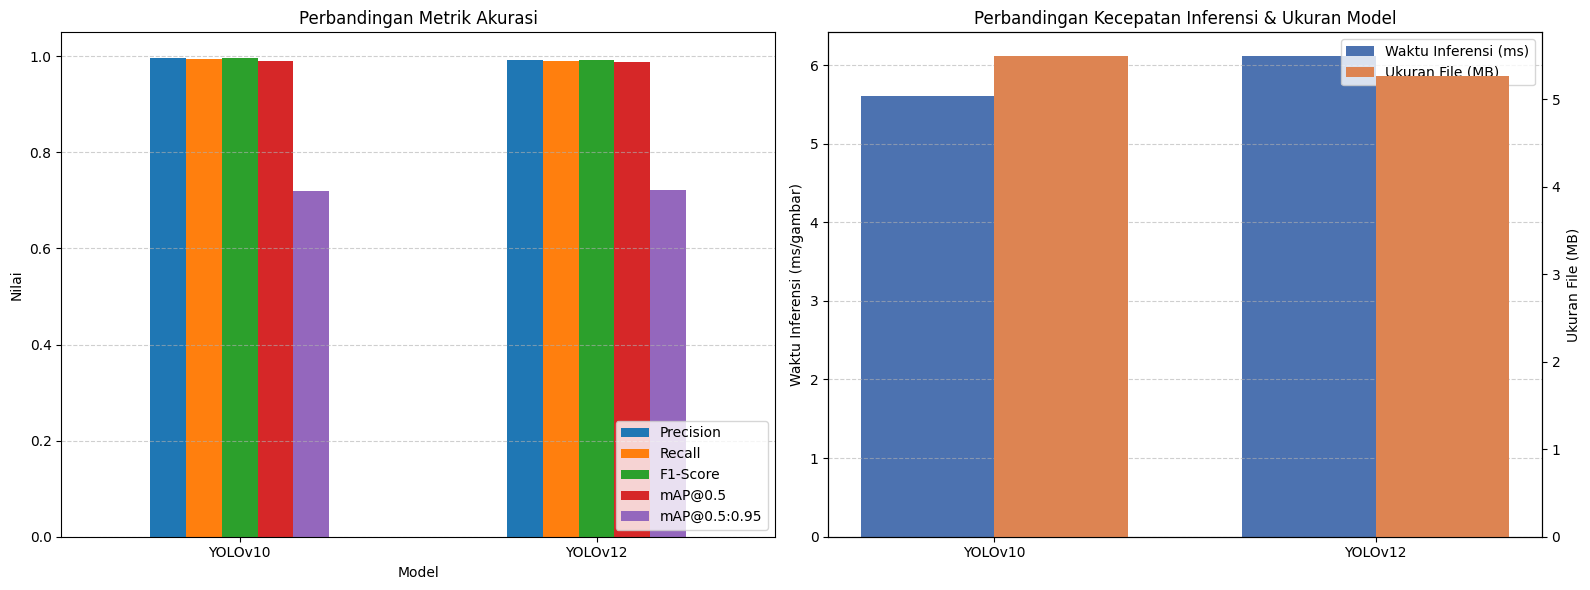

Grafik disimpan di: /content/drive/MyDrive/deteksi_kematangan_pala/hasil_training/grafik_perbandingan.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafik 1: Metrik akurasi ---
metrik_akurasi = ["Precision", "Recall", "F1-Score", "mAP@0.5", "mAP@0.5:0.95"]
comparison.set_index("Model")[metrik_akurasi].plot(kind="bar", ax=axes[0])
axes[0].set_title("Perbandingan Metrik Akurasi")
axes[0].set_ylabel("Nilai")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
axes[0].legend(loc="lower right")
axes[0].tick_params(axis="x", rotation=0)

# --- Grafik 2: Waktu inferensi & ukuran file ---
x = np.arange(len(comparison))
lebar = 0.35
ax2 = axes[1]
ax2b = ax2.twinx()

bar1 = ax2.bar(x - lebar/2, comparison["Waktu Inferensi (ms/gambar)"], lebar,
               label="Waktu Inferensi (ms)", color="#4C72B0")
bar2 = ax2b.bar(x + lebar/2, comparison["Ukuran File (MB)"], lebar,
                label="Ukuran File (MB)", color="#DD8452")

ax2.set_xticks(x)
ax2.set_xticklabels(comparison["Model"])
ax2.set_ylabel("Waktu Inferensi (ms/gambar)")
ax2b.set_ylabel("Ukuran File (MB)")
ax2.set_title("Perbandingan Kecepatan Inferensi & Ukuran Model")
ax2.grid(axis="y", linestyle="--", alpha=0.6)
ax2.legend(handles=[bar1, bar2], loc="upper right")

plt.tight_layout()
grafik_path = f"{DRIVE_PROJECT_DIR}/hasil_training/grafik_perbandingan.png"
plt.savefig(grafik_path, dpi=150)
plt.show()
print("Grafik disimpan di:", grafik_path)

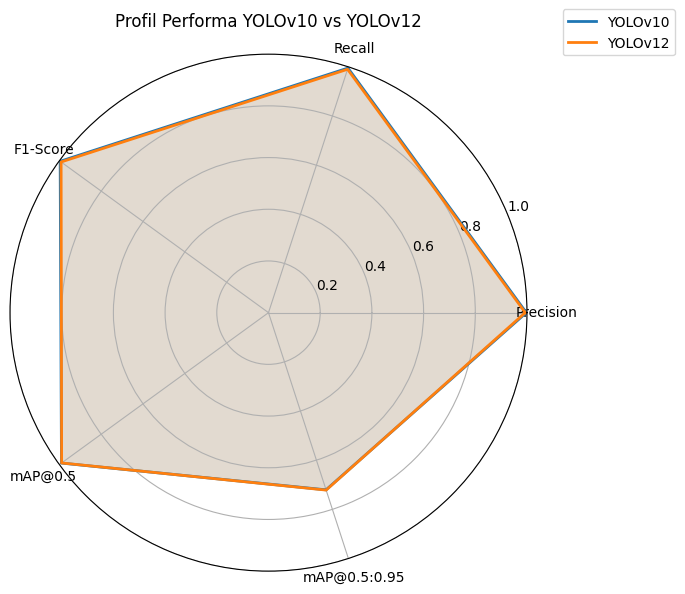

In [ ]:
# --- Radar chart: profil performa keseluruhan ---
label_radar = ["Precision", "Recall", "F1-Score", "mAP@0.5", "mAP@0.5:0.95"]
angka = len(label_radar)
sudut = np.linspace(0, 2 * np.pi, angka, endpoint=False).tolist()
sudut += sudut[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, baris in comparison.iterrows():
    nilai = baris[label_radar].tolist()
    nilai += nilai[:1]
    ax.plot(sudut, nilai, linewidth=2, label=baris["Model"])
    ax.fill(sudut, nilai, alpha=0.15)

ax.set_xticks(sudut[:-1])
ax.set_xticklabels(label_radar)
ax.set_ylim(0, 1)
ax.set_title("Profil Performa YOLOv10 vs YOLOv12", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# Menentukan Model Terbaik

In [ ]:
print("========== HASIL PERBANDINGAN ==========\n")
print(comparison.to_string(index=False))

print("\n--- Model Terbaik per Metrik ---")
for metrik in ["Precision", "Recall", "F1-Score", "mAP@0.5", "mAP@0.5:0.95"]:
    terbaik = comparison.loc[comparison[metrik].idxmax(), "Model"]
    print(f"{metrik:<28}: {terbaik}")

tercepat = comparison.loc[comparison["Waktu Inferensi (ms/gambar)"].idxmin(), "Model"]
print(f"{'Inferensi Tercepat':<28}: {tercepat}")

teringan = comparison.loc[comparison["Ukuran File (MB)"].idxmin(), "Model"]
print(f"{'Ukuran File Terkecil':<28}: {teringan}")

========== HASIL PERBANDINGAN ==========

  Model  Precision  Recall  F1-Score  mAP@0.5  mAP@0.5:0.95  Waktu Inferensi (ms/gambar)  Jumlah Parameter (juta)  Ukuran File (MB)
YOLOv10     0.9974  0.9949    0.9962   0.9900        0.7207                         5.60                     2.27              5.49
YOLOv12     0.9933  0.9900    0.9917   0.9892        0.7217                         6.11                     2.56              5.26

--- Model Terbaik per Metrik ---
Precision                   : YOLOv10
Recall                      : YOLOv10
F1-Score                    : YOLOv10
mAP@0.5                     : YOLOv10
mAP@0.5:0.95                : YOLOv12
Inferensi Tercepat          : YOLOv10
Ukuran File Terkecil        : YOLOv12


In [ ]:
# --- Skor gabungan (weighted score) ---
# Bobot dapat disesuaikan sesuai kebutuhan aplikasi (mis. jika kecepatan lebih penting
# daripada akurasi, perbesar bobot pada metrik kecepatan).
bobot = {
    "Precision": 0.15,
    "Recall": 0.15,
    "F1-Score": 0.15,
    "mAP@0.5": 0.20,
    "mAP@0.5:0.95": 0.35,
}

comparison["Skor Akhir"] = comparison.apply(
    lambda baris: round(sum(baris[m] * b for m, b in bobot.items()), 4), axis=1
)

model_terbaik = comparison.loc[comparison["Skor Akhir"].idxmax(), "Model"]

print("--- Skor Akhir (Weighted Score) ---")
print(comparison[["Model", "Skor Akhir"]].to_string(index=False))

print(f"\n>>> Berdasarkan skor gabungan, model terbaik untuk deteksi kematangan pala "
      f"adalah: {model_terbaik} <<<")

comparison

--- Skor Akhir (Weighted Score) ---
  Model  Skor Akhir
YOLOv10      0.8985
YOLOv12      0.8967

>>> Berdasarkan skor gabungan, model terbaik untuk deteksi kematangan pala adalah: YOLOv10 <<<


,Model,Precision,Recall,F1-Score,mAP@0.5,mAP@0.5:0.95,Waktu Inferensi (ms/gambar),Jumlah Parameter (juta),Ukuran File (MB),Skor Akhir
0,YOLOv10,0.9974,0.9949,0.9962,0.9900,0.7207,5.60,2.27,5.49,0.8985
1,YOLOv12,0.9933,0.9900,0.9917,0.9892,0.7217,6.11,2.56,5.26,0.8967
